In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clean = pd.read_csv("../data/retail_clean.csv", parse_dates=["InvoiceDate"])
sns.set_theme(style="whitegrid")
clean.shape

C:\Users\Piyush\AppData\Local\Temp\ipykernel_3900\1046884744.py:5: DtypeWarning: Columns (0: Invoice) have mixed types. Specify dtype option on import or set low_memory=False.
  clean = pd.read_csv("../data/retail_clean.csv", parse_dates=["InvoiceDate"])


(1003473, 9)

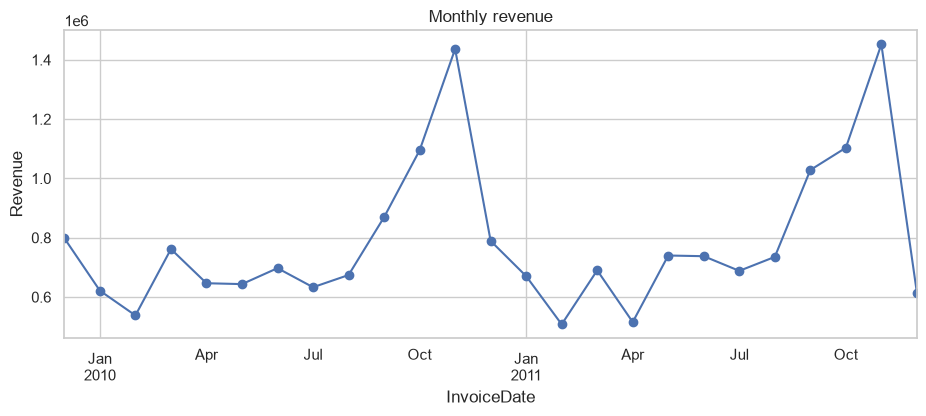

In [2]:
monthly = clean.set_index("InvoiceDate")["Revenue"].resample("MS").sum()
monthly.plot(figsize=(11, 4), marker="o", title="Monthly revenue")
plt.ylabel("Revenue")
plt.show()

Country
United Kingdom    85.5
EIRE               3.2
Netherlands        2.8
Germany            1.9
France             1.6
Australia          0.9
Spain              0.5
Switzerland        0.5
Sweden             0.4
Denmark            0.3
Name: Revenue, dtype: float64


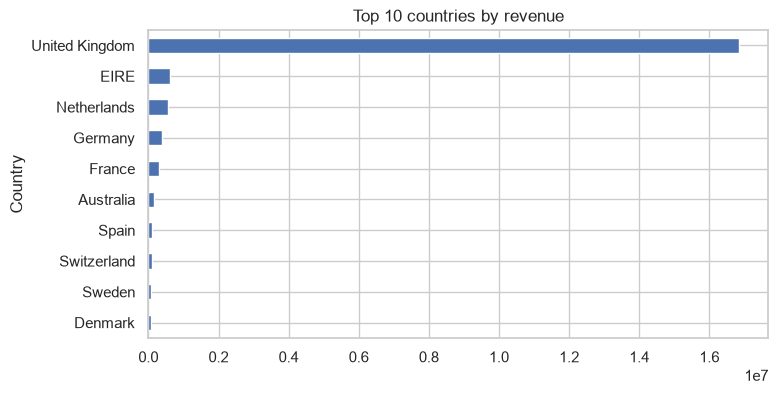

In [3]:
by_country = clean.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
print((by_country.head(10) / by_country.sum() * 100).round(1))

by_country.head(10).plot(kind="barh", figsize=(8, 4), title="Top 10 countries by revenue")
plt.gca().invert_yaxis()
plt.show()

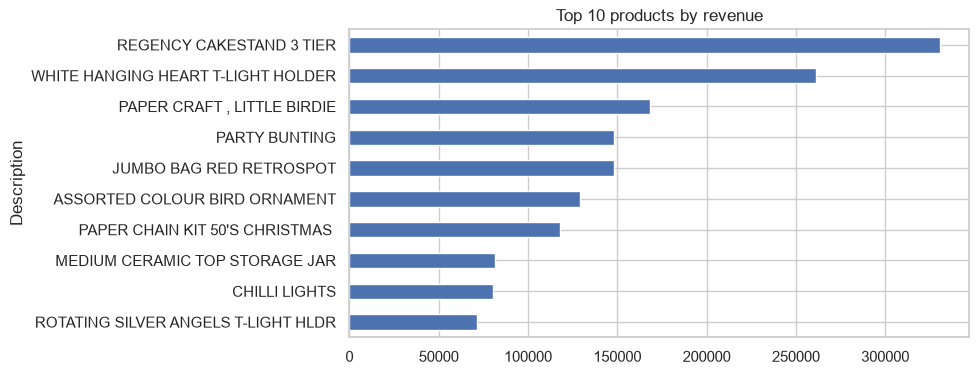

In [4]:
top_products = clean.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="barh", figsize=(8, 4), title="Top 10 products by revenue")
plt.gca().invert_yaxis()
plt.show()

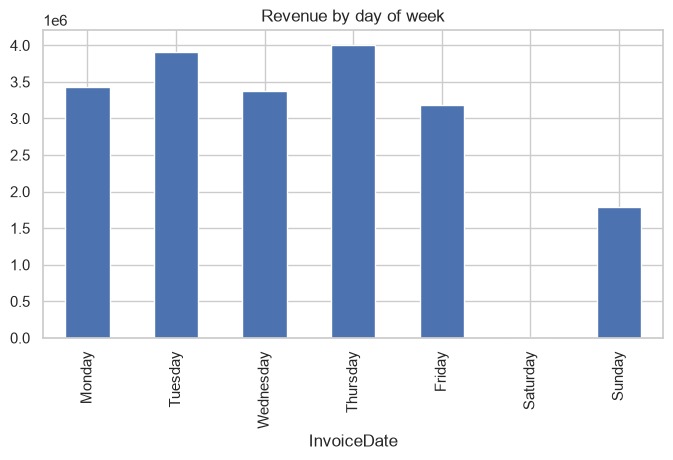

: 

In [ ]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_day = (clean.groupby(clean["InvoiceDate"].dt.day_name())["Revenue"]
          .sum().reindex(order))
by_day.plot(kind="bar", figsize=(8, 4), title="Revenue by day of week")
plt.show()